In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from nltk.corpus import stopwords
from collections import Counter
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import minimize
from matplotlib.lines import Line2D

## Importing the datasets

In [15]:
final_df_gpt41 = pd.read_csv("results_all_gpt4.1.csv")
final_df_gpt54 = pd.read_csv("results_all_gpt5.4.csv")
final_df_sonnet = pd.read_csv("results_all_sonnet4.6.csv")

In [16]:
comments_gpt41 = pd.read_csv("comments_all_gpt4.1.csv")
comments_gpt54 = pd.read_csv("comments_all_gpt5.4.csv")
comments_sonnet = pd.read_csv("comments_all_sonnet4.6.csv")

## 1. Feasibility Metrics

#### -> Did the LLMs respect the given constraints?

In [17]:
tickers = [
    "MMM.N","AMZN.OQ","AXP.N","AMGN.OQ","AAPL.OQ","BA.N","CAT.N","CVX.N",
    "CSCO.OQ","KO.N","DOW.N","GS.N","HD.N","HON.OQ","IBM.N","INTC.OQ",
    "JNJ.N","JPM.N","MCD.N","MRK.N","MSFT.OQ","NKE.N","PG.N","CRM.N",
    "TRV.N","UNH.N","VZ.N","V.N","WMT.N","DIS.N"
]
tickers_clean = [t.split(".")[0] for t in tickers]
n_assets = 30

In [18]:
def check_portfolio_detailed(group, n_assets, tickers_clean):
    weights = pd.to_numeric(group["weight"], errors="coerce")
    return {
        "negative": not (weights >= 0).all(),
        "sum_not_1": abs(weights.sum() - 1) >= 1e-6,
        "wrong_rows": len(group) != n_assets,
        "duplicates": not group["ticker"].is_unique,
        "ticker_mismatch": set(group["ticker"]) != set(tickers_clean)
    }

In [19]:
df_gpt41 = final_df_gpt41.copy()
df_gpt41["model"] = "gpt4.1"

df_gpt54 = final_df_gpt54.copy()
df_gpt54["model"] = "gpt5.4"

df_sonnet = final_df_sonnet.copy()
df_sonnet["model"] = "sonnet"

final_all = pd.concat([df_gpt41, df_gpt54, df_sonnet], ignore_index=True)

detailed_results = []

for (model, level, rep), group in final_all.groupby(["model", "level", "rep"]):
    res = check_portfolio_detailed(group, n_assets, tickers_clean)
    res["model"] = model
    res["level"] = level
    res["rep"] = rep
    detailed_results.append(res)
detailed_df = pd.DataFrame(detailed_results)

summary = (
    detailed_df
    .groupby(["model", "level"])
    .mean()
    .drop(columns=["rep"])
)

print(summary.round(3))

              negative  sum_not_1  wrong_rows  duplicates  ticker_mismatch
model  level                                                              
gpt4.1 L0          0.0      0.995       0.015       0.015            0.015
       L1          0.0      0.403       0.000       0.000            0.000
       L2          0.0      0.403       0.000       0.000            0.000
       L3          0.0      0.289       0.000       0.000            0.000
gpt5.4 L0          0.0      0.910       0.000       0.000            0.000
       L1          0.0      0.886       0.000       0.000            0.000
       L2          0.0      0.090       0.000       0.000            0.000
       L3          0.0      0.547       0.000       0.000            0.000
sonnet L0          0.0      0.955       0.000       0.000            0.000
       L1          0.0      1.000       0.000       0.000            0.000
       L2          0.0      1.000       0.000       0.000            0.000
       L3          0.0   

#### Clean datasets

In [ ]:
def repair_portfolio(group, tickers_clean, level=None, rep=None):

    g = group.copy()
    g = g[["ticker", "weight"]].copy()

    # Make weights numeric
    g["weight"] = pd.to_numeric(g["weight"], errors="coerce")

    repair_info = {
        "level": level,
        "rep": rep,
        "had_nan_weights": g["weight"].isna().any(),
        "had_negative_weights": False,
        "had_duplicates": False,
        "had_unexpected_tickers": False,
        "had_missing_tickers": False,
        "raw_rows": len(g),
        "raw_sum": g["weight"].sum(skipna=True)
    }

    # Drop rows with NaN weights
    g = g.dropna(subset=["weight"])

    if (g["weight"] < 0).any():
        repair_info["had_negative_weights"] = True
        g["weight"] = g["weight"].clip(lower=0)

    # Drop unexpected tickers
    unexpected = set(g["ticker"]) - set(tickers_clean)
    if unexpected:
        repair_info["had_unexpected_tickers"] = True
        g = g[g["ticker"].isin(tickers_clean)].copy()

    # Aggregate duplicates by summing
    if not g["ticker"].is_unique:
        repair_info["had_duplicates"] = True
        g = g.groupby("ticker", as_index=False)["weight"].sum()

    # Add missing tickers with zero weight
    missing = set(tickers_clean) - set(g["ticker"])
    if missing:
        repair_info["had_missing_tickers"] = True
        missing_df = pd.DataFrame({"ticker": list(missing), "weight": 0.0})
        g = pd.concat([g, missing_df], ignore_index=True)

    # Reorder to match universe
    g["ticker"] = pd.Categorical(g["ticker"], categories=tickers_clean, ordered=True)
    g = g.sort_values("ticker").reset_index(drop=True)

    # Normalize weights if sum > 0
    weight_sum = g["weight"].sum()
    repair_info["sum_before_norm"] = weight_sum

    if abs(weight_sum - 1) >= 1e-6:
        if weight_sum > 0:
            g["weight"] = g["weight"] / weight_sum
        else:
            g["weight"] = 1 / len(g)

    repair_info["sum_after_norm"] = g["weight"].sum()
    repair_info["final_rows"] = len(g)

    return g, repair_info

In [ ]:
repaired_groups = []

for (level, rep), group in final_df_gpt41.groupby(["level", "rep"]):
    repaired, info = repair_portfolio(
        group,
        tickers_clean=tickers_clean,
        level=level,
        rep=rep,
    )

    repaired["level"] = level
    repaired["rep"] = rep
    repaired_groups.append(repaired)

final_df_gpt41_repaired = pd.concat(repaired_groups, ignore_index=True)

In [22]:
repaired_groups = []

for (level, rep), group in final_df_gpt54.groupby(["level", "rep"]):
    repaired, info = repair_portfolio(
        group,
        tickers_clean=tickers_clean,
        level=level,
        rep=rep,
    )

    repaired["level"] = level
    repaired["rep"] = rep
    repaired_groups.append(repaired)

final_df_gpt54_repaired = pd.concat(repaired_groups, ignore_index=True)

In [23]:
repaired_groups = []

for (level, rep), group in final_df_sonnet.groupby(["level", "rep"]):
    repaired, info = repair_portfolio(
        group,
        tickers_clean=tickers_clean,
        level=level,
        rep=rep,
    )

    repaired["level"] = level
    repaired["rep"] = rep
    repaired_groups.append(repaired)

final_df_sonnet_repaired = pd.concat(repaired_groups, ignore_index=True)

## 2. Similarity Metrics

In [ ]:
# data
file_path = "DJIA.xlsx"
sheet_name = "Sheet1"

start_date = "2018-01-01"
end_date = "2024-06-30"

df = pd.read_excel(file_path, sheet_name=sheet_name)
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

weekly_returns = df[tickers].copy()
weekly_returns.columns = tickers_clean

weekly_returns = weekly_returns.loc[start_date:end_date]

if weekly_returns.empty:
    raise ValueError("No data found in the selected date range.")

# Weekly mean returns
mu_weekly = weekly_returns.mean()

# Weekly covariance matrix
Sigma_weekly = weekly_returns.cov()

In [25]:
# defining the metrics
def l1_distance(w1, w2):
    return float(np.abs(w1 - w2).sum())

def l2_distance(w1, w2):
    return float(np.sqrt(((w1 - w2) ** 2).sum()))

def weight_corr(w1, w2):
    if np.std(w1.values) == 0 or np.std(w2.values) == 0:
        return np.nan
    return float(np.corrcoef(w1.values, w2.values)[0, 1])

def top_k_overlap(w1, w2, k=5):
    top1 = set(w1.sort_values(ascending=False).head(k).index)
    top2 = set(w2.sort_values(ascending=False).head(k).index)
    return len(top1 & top2) / k

In [26]:
mu = mu_weekly.loc[tickers_clean].copy()
Sigma = Sigma_weekly.loc[tickers_clean, tickers_clean].copy()

def mean_variance_portfolio(mu_vec, Sigma_mat, lam=0.5):
    mu_vec = np.asarray(mu_vec).reshape(-1)
    Sigma_mat = np.asarray(Sigma_mat)
    n = len(mu_vec)

    def objective(w):
        return -(mu_vec @ w - (lam / 2.0) * (w @ Sigma_mat @ w))

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0, 1) for _ in range(n)]
    w0 = np.ones(n) / n

    res = minimize(
        objective,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not res.success:
        raise ValueError(f"MV optimization failed: {res.message}")

    return pd.Series(res.x, index=tickers_clean)

def min_variance_portfolio(Sigma_mat):
    Sigma_mat = np.asarray(Sigma_mat)
    n = Sigma_mat.shape[0]

    def objective(w):
        return w @ Sigma_mat @ w

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0, 1) for _ in range(n)]
    w0 = np.ones(n) / n

    res = minimize(
        objective,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not res.success:
        raise ValueError(f"MinVar optimization failed: {res.message}")

    return pd.Series(res.x, index=tickers_clean)

def equal_weight_portfolio(tickers):
    n = len(tickers)
    return pd.Series(np.ones(n) / n, index=tickers)

# benchmarks
w_eq = equal_weight_portfolio(tickers_clean)
w_mv = mean_variance_portfolio(mu.values, Sigma.values, lam=0.5)
w_minvar = min_variance_portfolio(Sigma.values)

benchmarks = {
    "EW": w_eq,
    "MV": w_mv,
    "MinVar": w_minvar
}

def average_portfolios_by_level(df_repaired, tickers):
    avg_dict = {}

    for level, group in df_repaired.groupby("level"):
        w = (
            group.groupby("ticker")["weight"]
            .mean()
            .reindex(tickers)
            .fillna(0.0)
        )

        # normalize just in case
        if w.sum() > 0:
            w = w / w.sum()

        avg_dict[level] = w

    return avg_dict

avg_gpt41 = average_portfolios_by_level(final_df_gpt41_repaired, tickers_clean)
avg_gpt54 = average_portfolios_by_level(final_df_gpt54_repaired, tickers_clean)
avg_sonnet = average_portfolios_by_level(final_df_sonnet_repaired, tickers_clean)

all_models = {
    "gpt4.1": avg_gpt41,
    "gpt5.4": avg_gpt54,
    "sonnet": avg_sonnet
}

results = []

for model_name, level_dict in all_models.items():
    for level, w_llm in level_dict.items():
        for bench_name, w_bench in benchmarks.items():
            results.append({
                "model": model_name,
                "level": level,
                "benchmark": bench_name,
                "L1_distance": l1_distance(w_llm, w_bench),
                "L2_distance": l2_distance(w_llm, w_bench),
                "correlation": weight_corr(w_llm, w_bench),
                "top5_overlap": top_k_overlap(w_llm, w_bench, k=5)
            })

similarity_df = pd.DataFrame(results)

/var/folders/mp/185tqzt15qd296cn272z83vh0000gp/T/ipykernel_94276/1549327487.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group.groupby("ticker")["weight"]
/var/folders/mp/185tqzt15qd296cn272z83vh0000gp/T/ipykernel_94276/1549327487.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group.groupby("ticker")["weight"]
/var/folders/mp/185tqzt15qd296cn272z83vh0000gp/T/ipykernel_94276/1549327487.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

In [28]:
table_l1 = similarity_df.pivot_table(
    index=["model", "level"],
    columns="benchmark",
    values="L1_distance"
)

print("L1_distance")
print(table_l1.round(3))

L1_distance
benchmark        EW     MV  MinVar
model  level                      
gpt4.1 L0     0.231  1.782   1.076
       L1     1.267  1.106   1.278
       L2     1.594  0.723   1.778
       L3     1.598  0.905   1.781
gpt5.4 L0     0.344  1.798   0.918
       L1     0.802  1.677   0.748
       L2     1.315  1.442   0.952
       L3     0.924  1.513   1.090
sonnet L0     0.208  1.790   1.061
       L1     1.231  1.380   1.050
       L2     1.331  1.335   1.067
       L3     1.297  1.242   1.192


In [29]:
table_l2 = similarity_df.pivot_table(
    index=["model", "level"],
    columns="benchmark",
    values="L2_distance"
)

print("L2_distance")
print(table_l2.round(3))

L2_distance
benchmark        EW     MV  MinVar
model  level                      
gpt4.1 L0     0.050  0.653   0.245
       L1     0.349  0.458   0.385
       L2     0.488  0.368   0.562
       L3     0.435  0.420   0.525
gpt5.4 L0     0.073  0.662   0.215
       L1     0.163  0.631   0.211
       L2     0.314  0.595   0.284
       L3     0.201  0.575   0.276
sonnet L0     0.045  0.656   0.243
       L1     0.263  0.541   0.301
       L2     0.290  0.534   0.319
       L3     0.297  0.493   0.347


In [30]:
table_top5 = similarity_df.pivot_table(
    index=["model", "level"],
    columns="benchmark",
    values="top5_overlap"
)

print("top5 overlap")
print(table_top5.round(3))

top5 overlap
benchmark      EW   MV  MinVar
model  level                  
gpt4.1 L0     0.0  0.4     0.4
       L1     0.6  0.6     0.2
       L2     0.4  0.6     0.0
       L3     0.2  0.4     0.0
gpt5.4 L0     0.2  0.2     0.6
       L1     0.2  0.2     0.8
       L2     0.2  0.4     0.6
       L3     0.4  0.6     0.4
sonnet L0     0.2  0.6     0.4
       L1     0.4  0.6     0.4
       L2     0.4  0.6     0.4
       L3     0.4  0.6     0.4


In [31]:
table_corr = similarity_df.pivot_table(
    index=["model", "level"],
    columns="benchmark",
    values="correlation"
)

print("correlation")
print(table_corr.round(3))

correlation
benchmark        MV  MinVar
model  level               
gpt4.1 L0     0.623   0.276
       L1     0.794   0.217
       L2     0.854  -0.052
       L3     0.806  -0.098
gpt5.4 L0     0.343   0.637
       L1     0.426   0.561
       L2     0.493   0.517
       L3     0.642   0.285
sonnet L0     0.618   0.333
       L1     0.677   0.323
       L2     0.671   0.320
       L3     0.770   0.214


## 3. Performance Metrics

In [32]:
def portfolio_return(w, mu):
    return float(w @ mu)

def portfolio_variance(w, Sigma):
    return float(w @ Sigma @ w)

def portfolio_volatility(w, Sigma):
    return float(np.sqrt(portfolio_variance(w, Sigma)))

def sharpe_ratio(w, mu, Sigma, rf=0):
    ret = portfolio_return(w, mu)
    vol = portfolio_volatility(w, Sigma)
    return (ret - rf) / vol

def herfindahl(w):
    return float((w**2).sum())

In [33]:
perf_results = []

for model_name, level_dict in all_models.items(): #LLM portfolios
    for level, w in level_dict.items():
        
        perf_results.append({
            "Portfolio": f"{model_name}-{level}",
            "Return": portfolio_return(w.values, mu.values),
            "Volatility": portfolio_volatility(w.values, Sigma.values),
            "Sharpe": sharpe_ratio(w.values, mu.values, Sigma.values),
            "HHI": herfindahl(w.values)
        })

# Benchmarks
for name, w in benchmarks.items():
    perf_results.append({
        "Portfolio": name,
        "Return": portfolio_return(w.values, mu.values),
        "Volatility": portfolio_volatility(w.values, Sigma.values),
        "Sharpe": sharpe_ratio(w.values, mu.values, Sigma.values),
        "HHI": herfindahl(w.values)
    })

perf_df = pd.DataFrame(perf_results).round(4)
perf_df

,Portfolio,Return,Volatility,Sharpe,HHI
0,gpt4.1-L0,0.0024,0.0251,0.0956,0.0358
1,gpt4.1-L1,0.0041,0.0260,0.1562,0.1555
2,gpt4.1-L2,0.0046,0.0314,0.1468,0.2717
3,gpt4.1-L3,0.0044,0.0313,0.1411,0.2230
4,gpt5.4-L0,0.0023,0.0238,0.0987,0.0387
5,gpt5.4-L1,0.0029,0.0227,0.1276,0.0598
6,gpt5.4-L2,0.0036,0.0226,0.1596,0.1322
7,gpt5.4-L3,0.0036,0.0246,0.1446,0.0739
8,sonnet-L0,0.0024,0.0251,0.0961,0.0354
9,sonnet-L1,0.0038,0.0249,0.1523,0.1026


In [34]:
risk_return_rows = []

# benchmarks
for bench_name, w in benchmarks.items():
    risk_return_rows.append({
        "model": "benchmark",
        "level": bench_name,
        "portfolio": bench_name,
        "exp_return": portfolio_return(w.values, mu.values),
        "volatility": portfolio_volatility(w.values, Sigma.values)
    })

# LLM averages
for model_name, level_dict in all_models.items():
    for level, w in level_dict.items():
        risk_return_rows.append({
            "model": model_name,
            "level": level,
            "portfolio": f"{model_name}-{level}",
            "exp_return": portfolio_return(w.values, mu.values),
            "volatility": portfolio_volatility(w.values, Sigma.values)
        })

risk_return_df = pd.DataFrame(risk_return_rows)

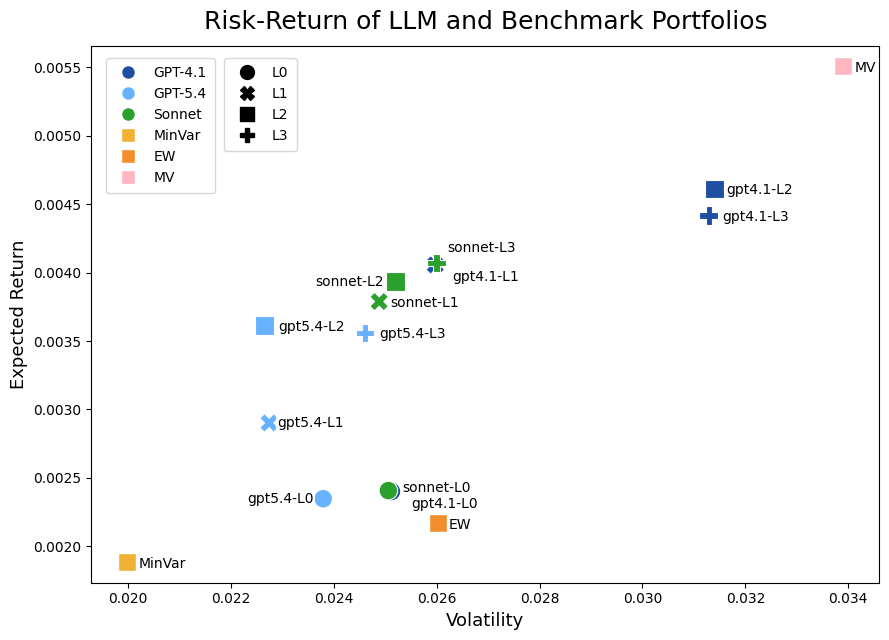

In [35]:
model_colors = {
    "gpt4.1": "#1f4fa3",   # dark blue
    "gpt5.4": "#66b2ff",   # light blue
    "sonnet": "#2ca02c",   # green
}

benchmark_colors = {
    "MinVar": "#f2b134",   # yellow-orange
    "EW": "#f28e2b",       # orange
    "MV": "#ffb6c1",       # purple
}

level_markers = {
    "L0": "o",
    "L1": "X",
    "L2": "s",
    "L3": "P",
}

label_offsets = { #to customize the labels position
    "MinVar": (8, -1),
    "EW": (8, -1),
    "MV": (8, -1),

    "gpt4.1-L0": (14, -9),
    "gpt4.1-L1": (12, -9),
    "gpt4.1-L2": (8, -1),
    "gpt4.1-L3": (10, -1),

    "gpt5.4-L0": (-55, 0),
    "gpt5.4-L1": (6, 0),
    "gpt5.4-L2": (10, -1),
    "gpt5.4-L3": (10, -1),

    "sonnet-L0": (10, 2),
    "sonnet-L1": (8, -1),
    "sonnet-L2": (-58, 0),
    "sonnet-L3": (8, 11),
}

fig, ax = plt.subplots(figsize=(9, 6.5))

bench_df = risk_return_df[risk_return_df["model"] == "benchmark"]

for _, row in bench_df.iterrows():
    ax.scatter(
        row["volatility"],
        row["exp_return"],
        s=180,
        marker="s",
        color=benchmark_colors.get(row["portfolio"], "#f28e2b"),
        edgecolor="white",
        linewidth=1.0,
        zorder=3
    )

llm_df = risk_return_df[risk_return_df["model"] != "benchmark"]

sns.scatterplot(
    data=llm_df,
    x="volatility",
    y="exp_return",
    hue="model",
    style="level",
    palette=model_colors,
    markers=level_markers,
    s=180,
    edgecolor="white",
    linewidth=0.8,
    legend=False,
    ax=ax,
    zorder=4
)

for _, row in risk_return_df.iterrows():
    name = row["portfolio"]
    dx, dy = label_offsets.get(name)

    ax.annotate(
        name,
        xy=(row["volatility"], row["exp_return"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75),
        zorder=5
    )

#models and benchmarks
legend1_handles = [
    Line2D([0], [0], marker='o', color='w', label='GPT-4.1', 
            markerfacecolor=model_colors["gpt4.1"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='GPT-5.4',
           markerfacecolor=model_colors["gpt5.4"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Sonnet',
           markerfacecolor=model_colors["sonnet"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='MinVar',
           markerfacecolor=benchmark_colors["MinVar"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='EW',
           markerfacecolor=benchmark_colors["EW"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='MV',
           markerfacecolor=benchmark_colors["MV"], markeredgecolor="white", markersize=10),
]

legend1 = ax.legend(
    handles=legend1_handles,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    fontsize=10,
    borderpad=0.6,
    labelspacing=0.5,
    handletextpad=0.8
)
# levels
legend2_handles = [
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='L0', markersize=10),
    Line2D([0], [0], marker='X', color='black', linestyle='None', label='L1', markersize=10),
    Line2D([0], [0], marker='s', color='black', linestyle='None', label='L2', markersize=10),
    Line2D([0], [0], marker='P', color='black', linestyle='None', label='L3', markersize=10),
]

legend2 = ax.legend(
    handles=legend2_handles,
    loc="upper left",
    bbox_to_anchor=(0.16, 0.99),
    frameon=True,
    fontsize=10,
    borderpad=0.6,
    labelspacing=0.5,
    handletextpad=0.8
)

ax.add_artist(legend1)

ax.set_title("Risk-Return of LLM and Benchmark Portfolios", fontsize=18, pad=12)
ax.set_xlabel("Volatility", fontsize=13)
ax.set_ylabel("Expected Return", fontsize=13)

xpad = 0.0007
ypad = 0.00015
ax.set_xlim(risk_return_df["volatility"].min() - xpad, risk_return_df["volatility"].max() + xpad)
ax.set_ylim(risk_return_df["exp_return"].min() - ypad, risk_return_df["exp_return"].max() + ypad)

plt.tight_layout()
plt.show()

## 4. Robustness Analysis

#### Variability of the weights

In [38]:
weight_std = (
    final_df_gpt41_repaired
    .groupby(["level", "ticker"])["weight"]
    .std()
    .reset_index()
)

level_variability = weight_std.groupby("level")["weight"].mean()
print("gpt4.1")
print(level_variability) #variability of weights

gpt4.1
level
L0    0.003150
L1    0.028244
L2    0.019851
L3    0.011814
Name: weight, dtype: float64


/var/folders/mp/185tqzt15qd296cn272z83vh0000gp/T/ipykernel_94276/2998351239.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["level", "ticker"])["weight"]


In [39]:
weight_std = (
    final_df_gpt54_repaired
    .groupby(["level", "ticker"])["weight"]
    .std()
    .reset_index()
)

level_variability = weight_std.groupby("level")["weight"].mean()
print("gpt5.4")
print(level_variability) #variability of weights

gpt5.4
level
L0    0.001767
L1    0.002526
L2    0.017305
L3    0.008768
Name: weight, dtype: float64


/var/folders/mp/185tqzt15qd296cn272z83vh0000gp/T/ipykernel_94276/60780517.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["level", "ticker"])["weight"]


In [40]:
weight_std = (
    final_df_sonnet_repaired
    .groupby(["level", "ticker"])["weight"]
    .std()
    .reset_index()
)

level_variability = weight_std.groupby("level")["weight"].mean()
print("sonnet")
print(level_variability) #variability of weights

sonnet
level
L0    0.002352
L1    0.005336
L2    0.007154
L3    0.007667
Name: weight, dtype: float64


/var/folders/mp/185tqzt15qd296cn272z83vh0000gp/T/ipykernel_94276/3269266123.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["level", "ticker"])["weight"]


#### Top holdings stability (=> overlap)

In [41]:
def compute_top_overlap(df_repaired, model_name, k=5):
    overlaps = []

    for level, group in df_repaired.groupby("level"):
        reps = group["rep"].unique()

        for i in range(len(reps)):
            for j in range(i+1, len(reps)):
                df_i = group[group["rep"] == reps[i]]
                df_j = group[group["rep"] == reps[j]]

                top_i = set(df_i.sort_values("weight", ascending=False)["ticker"].head(k))
                top_j = set(df_j.sort_values("weight", ascending=False)["ticker"].head(k))

                overlap = len(top_i & top_j) / k

                overlaps.append({
                    "model": model_name,
                    "level": level,
                    "overlap": overlap
                })

    overlap_df = pd.DataFrame(overlaps)

    return overlap_df.groupby(["model", "level"])["overlap"].mean().reset_index() #stability for top holdings

In [42]:
overlap_gpt41 = compute_top_overlap(final_df_gpt41_repaired, "gpt4.1")
overlap_gpt54 = compute_top_overlap(final_df_gpt54_repaired, "gpt5.4")
overlap_sonnet = compute_top_overlap(final_df_sonnet_repaired, "sonnet")

overlap_all = pd.concat([overlap_gpt41, overlap_gpt54, overlap_sonnet], ignore_index=True)

print(overlap_all)

     model level   overlap
0   gpt4.1    L0  0.834776
1   gpt4.1    L1  0.635682
2   gpt4.1    L2  0.774905
3   gpt4.1    L3  0.861144
4   gpt5.4    L0  0.896090
5   gpt5.4    L1  0.878677
6   gpt5.4    L2  0.820856
7   gpt5.4    L3  0.914955
8   sonnet    L0  0.779960
9   sonnet    L1  0.946000
10  sonnet    L2  0.887313
11  sonnet    L3  0.782030


#### Cosine similarity

In [43]:
model = SentenceTransformer("all-MiniLM-L6-v2")

def embed_texts(texts):
    return model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)

In [44]:
def average_pairwise_similarity(texts, model):
    if len(texts) < 2:
        return np.nan
    emb = model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
    sim = cosine_similarity(emb)
    upper = sim[np.triu_indices(len(sim), k=1)]
    return upper.mean()

results = []

for level in comments_gpt41["level"].unique():
    texts = comments_gpt41.loc[comments_gpt41["level"] == level, "comment"].fillna("").tolist()
    avg_sim = average_pairwise_similarity(texts, model)
    results.append({"model": "gpt4.1", "level": level, "avg_cosine_similarity": avg_sim})

for level in comments_gpt54["level"].unique():
    texts = comments_gpt54.loc[comments_gpt54["level"] == level, "comment"].fillna("").tolist()
    avg_sim = average_pairwise_similarity(texts, model)
    results.append({"model": "gpt5.4", "level": level, "avg_cosine_similarity": avg_sim})

for level in comments_sonnet["level"].unique():
    texts = comments_sonnet.loc[comments_sonnet["level"] == level, "comment"].fillna("").tolist()
    avg_sim = average_pairwise_similarity(texts, model)
    results.append({"model": "sonnet", "level": level, "avg_cosine_similarity": avg_sim})

similarity_df = pd.DataFrame(results)
print(similarity_df)

     model level  avg_cosine_similarity
0   gpt4.1    L0               0.827282
1   gpt4.1    L1               0.895275
2   gpt4.1    L2               0.896070
3   gpt4.1    L3               0.879269
4   gpt5.4    L0               0.844281
5   gpt5.4    L1               0.855779
6   gpt5.4    L2               0.855910
7   gpt5.4    L3               0.855898
8   sonnet    L0               0.869243
9   sonnet    L1               0.870140
10  sonnet    L2               0.915808
11  sonnet    L3               0.847127


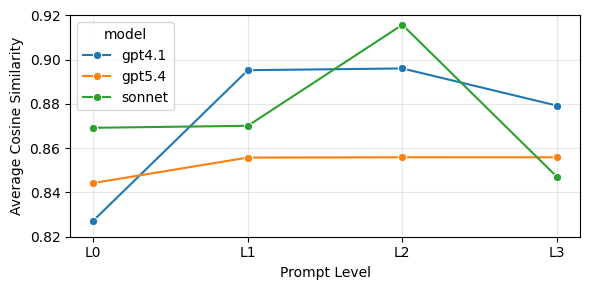

In [45]:
plt.figure(figsize=(6, 3))

sns.lineplot(
    data=similarity_df,
    x="level",
    y="avg_cosine_similarity",
    hue="model",
    marker="o"
)
plt.ylabel("Average Cosine Similarity")
plt.xlabel("Prompt Level")
plt.ylim(0.82, 0.92)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Semantic Analysis

In [46]:
def clean_text(x):
    return str(x).lower()

for df in [comments_gpt41, comments_gpt54, comments_sonnet]:
    df["comment_clean"] = df["comment"].apply(clean_text) #lowering the text

#### Detect Keywords

In [47]:
# defining some semantic categories for the analysis
semantic_dict = {
    "diversification": ["diversified", "diversification", "spread", "balance"],
    "risk": ["risk", "volatility", "variance"],
    "return": ["return", "expected return", "higher return"],
    "covariance": ["covariance", "correlation"],
    "optimization": ["optimize", "optimization", "maximize", "objective"],
    "mean_variance": ["mean-variance", "mean variance"],
    "constraints": ["constraint", "no short", "non-negative", "sum"],
    "heuristic": ["stable", "large", "defensive", "sector"]
}

In [48]:
def detect_keywords(text, keywords):
    return any(k in text for k in keywords)

for name, keywords in semantic_dict.items():
    comments_gpt41[name] = comments_gpt41["comment_clean"].apply(lambda x: detect_keywords(x, keywords))

for name, keywords in semantic_dict.items():
    comments_gpt54[name] = comments_gpt54["comment_clean"].apply(lambda x: detect_keywords(x, keywords))

for name, keywords in semantic_dict.items():
    comments_sonnet[name] = comments_sonnet["comment_clean"].apply(lambda x: detect_keywords(x, keywords))

In [49]:
semantic_summary_gpt41 = comments_gpt41.groupby("level")[list(semantic_dict.keys())].mean()
semantic_summary_gpt54 = comments_gpt54.groupby("level")[list(semantic_dict.keys())].mean()
semantic_summary_sonnet = comments_sonnet.groupby("level")[list(semantic_dict.keys())].mean()

In [50]:
def compute_semantic(df): #compare the various models
    for name, keywords in semantic_dict.items():
        df[name] = df["comment_clean"].apply(lambda x: detect_keywords(x, keywords))
    return df.groupby("level")[list(semantic_dict.keys())].mean()

summary_gpt41 = compute_semantic(comments_gpt41)
summary_gpt54 = compute_semantic(comments_gpt54)
summary_sonnet = compute_semantic(comments_sonnet)

In [51]:
# compare the three models together
summary_gpt41["model"] = "gpt4.1"
summary_gpt54["model"] = "gpt5.4"
summary_sonnet["model"] = "sonnet"

all_semantic = pd.concat([summary_gpt41, summary_gpt54, summary_sonnet])

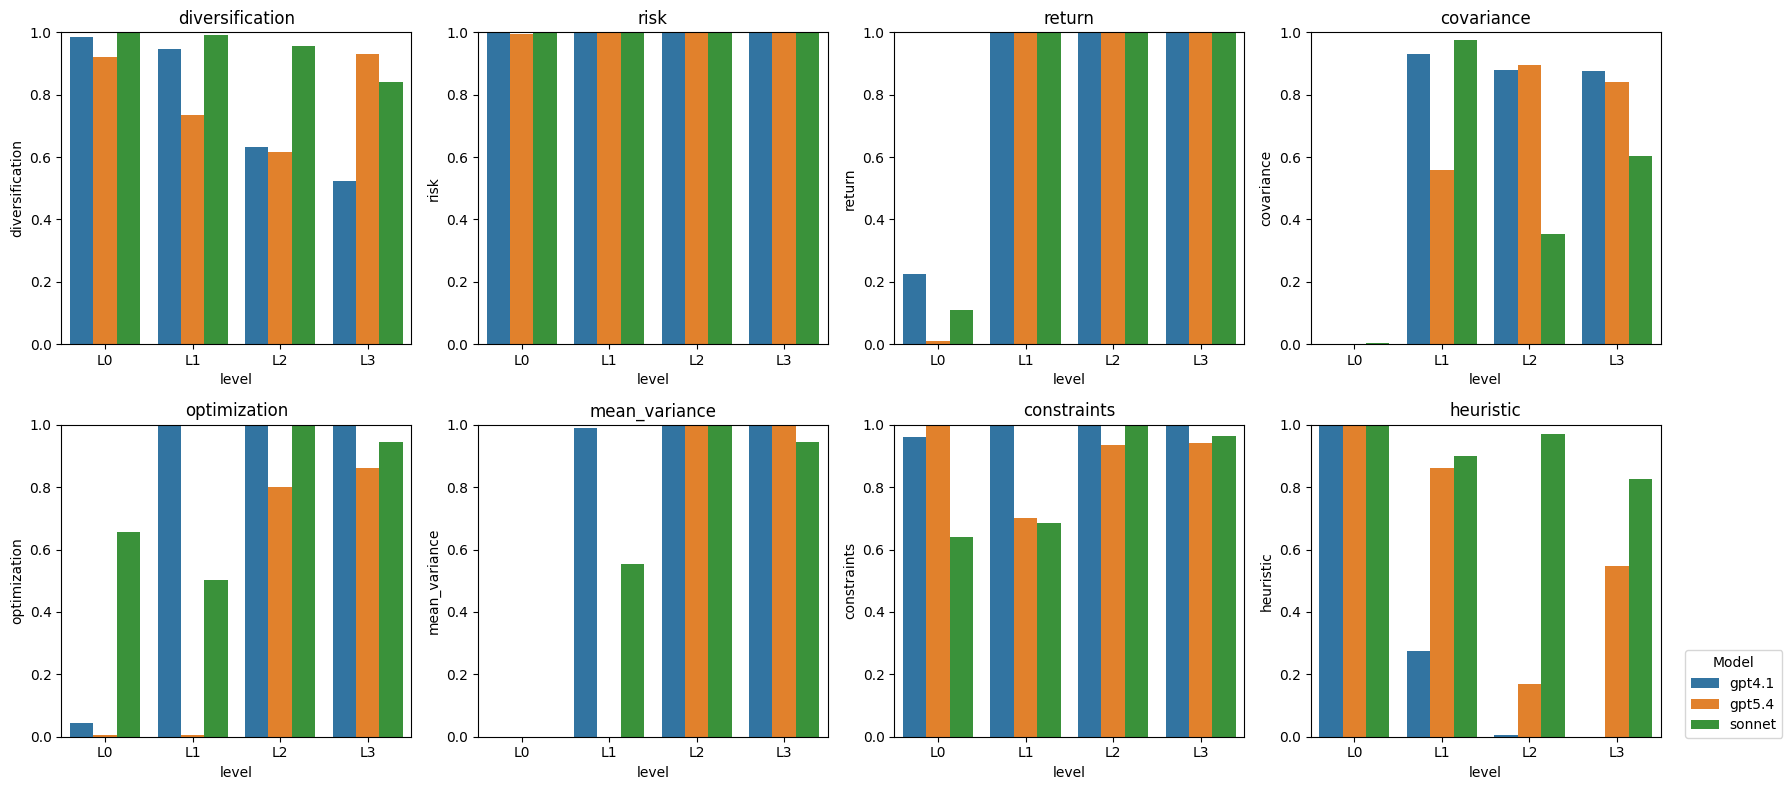

In [52]:
features = [
    "diversification",
    "risk",
    "return",
    "covariance",
    "optimization",
    "mean_variance",
    "constraints",
    "heuristic"
]
df_plot = all_semantic.reset_index()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.barplot(
        data=df_plot,
        x="level",
        y=feature,
        hue="model",
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_ylim(0, 1)

    axes[i].get_legend().remove()

plt.legend(title="Model", bbox_to_anchor=(1.05, 0.3))
plt.tight_layout()
plt.show()

#### Heatmap to show the changes in semantic features

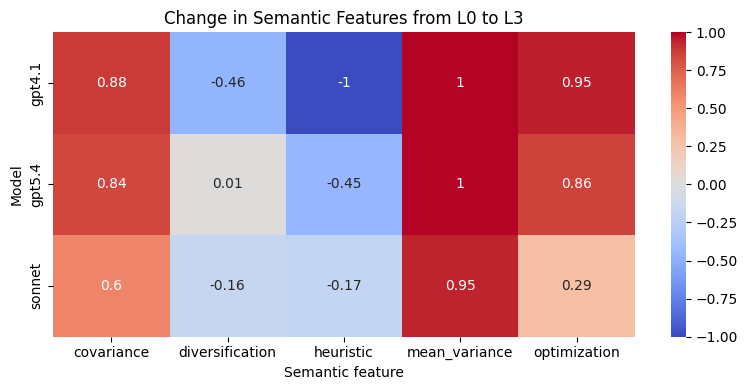

In [53]:
features_plot = [
    "diversification",
    "heuristic",
    "covariance",
    "optimization",
    "mean_variance"
]

delta = (
    all_semantic
    .reset_index()
    .pivot_table(index=["model", "level"], values=features_plot)
)

# L3 - L0 within each model
delta = delta.groupby(level=0).apply(lambda x: x.xs("L3", level=1) - x.xs("L0", level=1))

# clean row names
delta.index = delta.index.get_level_values(0)

plt.figure(figsize=(8, 4))
sns.heatmap(
    delta,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Change in Semantic Features from L0 to L3")
plt.xlabel("Semantic feature")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

#### Top words (excluding stopwords)

In [54]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "portfolio", "weights", "weight", "constructed", "investor",
    "using", "use", "based", "approach", "given", "expected",
    "risk", "return"
}

stop_words = stop_words.union(custom_stopwords)

def top_words(df, level, n=10):
    text = " ".join(df[df["level"] == level]["comment_clean"])

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    words = text.split()

    # remove stopwords and short words
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return Counter(words).most_common(n)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dimonopoli/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [55]:
print("L0:", top_words(comments_gpt41, "L0"))
print("L3:", top_words(comments_gpt41, "L3"))

L0: [('stocks', 236), ('sectors', 224), ('diversification', 216), ('across', 210), ('higher', 204), ('stable', 203), ('large', 200), ('companies', 188), ('nonnegative', 168), ('sum', 150)]
L3: [('maximizing', 204), ('returns', 203), ('constraints', 202), ('meanvariance', 200), ('optimization', 188), ('full', 187), ('concentrated', 185), ('riskadjusted', 182), ('minus', 179), ('investment', 172)]


In [56]:
print("L0:", top_words(comments_gpt54, "L0"))
print("L3:", top_words(comments_gpt54, "L3"))

L0: [('healthcare', 203), ('staples', 202), ('cyclical', 202), ('defensive', 201), ('consumer', 201), ('names', 201), ('diversified', 199), ('stocks', 197), ('technology', 192), ('across', 186)]
L3: [('names', 305), ('longonly', 236), ('meanvariance', 201), ('lambda', 201), ('stocks', 191), ('zero', 190), ('constrained', 188), ('optimization', 168), ('returns', 166), ('riskadjusted', 164)]


In [57]:
print("L0:", top_words(comments_sonnet, "L0"))
print("L3:", top_words(comments_sonnet, "L3"))

L0: [('stocks', 318), ('lower', 276), ('across', 250), ('diversification', 237), ('names', 207), ('riskaverse', 206), ('jnj', 200), ('wmt', 192), ('volatility', 191), ('msft', 186)]
L3: [('assets', 471), ('returns', 356), ('received', 309), ('mrk', 220), ('aapl', 218), ('msft', 218), ('wmt', 213), ('negative', 205), ('mmm', 201), ('intc', 201)]
